# Error models: there is a right way and many wrong ways

We are going to fit the same data with the same model six times over, changing
only one thing: the covariance we declare.  The point of the notebook is that
this choice *is* the statistical model.  It is not a detail we tune at the end;
it decides what the posterior says, and whether the truth is inside it.

Along the way we infer a noise level the experiment never reported, add a
correlated systematic, and get it wrong on purpose so we can see what the
classic mistake does to the answer.

Recipes: 2, 4, 19

In [1]:
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
import plotstyle
from scipy import stats

import rxmc as rx
from rxmc import terms as T

plotstyle.use()

## Where a $\chi^2$ comes from

Every fit assumes a likelihood, whether or not anyone writes it down.  Counting
events in a bin gives a [binomial](https://en.wikipedia.org/wiki/Binomial_distribution),
then a [Poisson](https://en.wikipedia.org/wiki/Poisson_distribution), then — with
many counts — a [normal](https://en.wikipedia.org/wiki/Normal_distribution).  If
the bins are independent, that is a diagonal
[multivariate normal](https://en.wikipedia.org/wiki/Multivariate_normal_distribution),
and its logarithm is $-\chi^2/2$.

Each of those steps is an assumption: that the points are independent, that our
model can reproduce the truth exactly, and that the errors are what the
experiment says they are.  When one of them fails, the honest generalisation is
not to abandon the normal but to *model its covariance*,

$$\log p(\mathbf{y}\mid\theta) = -\tfrac12 (\mathbf{y}-\mathbf{y}_m)^\mathsf{T}
\Sigma^{-1}(\mathbf{y}-\mathbf{y}_m) - \tfrac12\log\det\Sigma + \text{const},$$

so that $\Sigma$ carries the statistical errors, the correlated systematics, and
whatever we had to infer.  In `rxmc` a covariance is a sum of terms, and the rest
of this notebook is a tour of what choosing them does.

## Data with a defect the experiment did not report

Our data are a line with 5 % relative noise, multiplied by one overall
normalisation that came out 10 % low.  The experiment reports the noise
correctly and says nothing at all about the normalisation — which is exactly
the situation we are usually in.

In [2]:
rng = np.random.default_rng(16)
truth = {"m": 0.6, "b": 2.0}
x = np.linspace(0.01, 1.0, 15)
y_true = truth["m"] * x + truth["b"]
noise_fraction, sys_fraction = 0.05, 0.10
scale = 1.0 - sys_fraction  # the realised normalisation, one sigma low
y_meas = (y_true + rng.normal(0.0, noise_fraction * y_true)) * scale
data = rx.Dataset(x, y_meas, noise_fraction * y_meas, label="biased")
data

Dataset('biased', n=15)

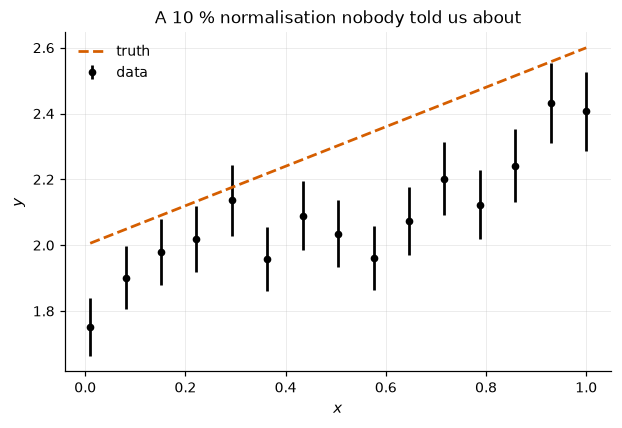

In [3]:
fig, ax = plt.subplots()
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", label="data")
ax.plot(x, y_true, "--", color=plotstyle.COLOURS[1], label="truth")
ax.set(xlabel="$x$", ylabel="$y$", title="A 10 % normalisation nobody told us about")
ax.legend()
plt.show()

## The model, a prior, and a way to run the ladder

We put the prior deliberately far from the truth, so that the data and not the
prior decide where we end up.  Then we write three small helpers we will reuse
on every rung: `fit` runs emcee on any problem, `band` pushes posterior rows
through the model on a fine grid, and `summary` prints the columns by name.

In [4]:
m = rx.Parameter("m", prior=stats.norm(2.0, 2.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(5.0, 2.0), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
x_fine = np.linspace(0.0, 1.0, 40)
comp = rx.Comparison(data, line)

In [5]:
def fit(problem, seed, n_walkers=24, n_steps=1800):
    sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return sampler.get_chain(discard=n_steps // 3, thin=5, flat=True)


def band(problem, samples, levels=(5, 95)):
    on_fine = line.bind(x_fine)
    cols = problem.columns(line.params)
    return rx.predictive.predictive_band(
        [on_fine(*s[cols]) for s in samples[::10]], levels=levels
    )


def summary(problem, samples):
    return "  ".join(
        f"{n} = {samples[:, i].mean():.3f} +/- {samples[:, i].std():.3f}"
        for i, n in enumerate(problem.names)
    )

## 1. Reported statistics only

The default covariance is the diagonal of `y_err`.  Nothing in it knows about
the normalisation, so we should expect a posterior that is precise and wrong —
the worst combination.

In [6]:
p_stat = rx.Problem([rx.Constraint([comp])])
s_stat = fit(p_stat, seed=1)
print(summary(p_stat, s_stat))

m = 0.483 +/- 0.087  b = 1.836 +/- 0.049


## 2. Inferring the noise level (recipe 2)

Suppose the experiment had not reported errors at all.  We can infer them:
`T.noise_fraction` puts a free relative noise $\sigma_i = \epsilon\, y_{m,i}$
on the diagonal, sampled in log space, and `statistical=False` drops the
reported diagonal so the inferred one replaces it rather than piling on top of
it.  (`T.noise` is the constant-floor variant, $\sigma_i = \epsilon$.)

In [7]:
log_eps = rx.Parameter(
    "log_eps", prior=stats.norm(np.log(0.05), 1.0), latex=r"\log\epsilon"
)
p_noise = rx.Problem(
    [rx.Constraint([comp], terms=[T.noise_fraction(log_eps)], statistical=False)]
)
s_noise = fit(p_noise, seed=2)
print(p_noise.names)
print(summary(p_noise, s_noise))
inferred = np.exp(s_noise[:, 2]).mean()
print(f"inferred noise fraction: {inferred:.3f}   (generated with {noise_fraction})")

['m', 'b', 'log_eps']
m = 0.531 +/- 0.277  b = 1.909 +/- 0.404  log_eps = -2.981 +/- 0.425
inferred noise fraction: 0.061   (generated with 0.05)


## 3. The reported systematic, as a correlated mode

If the experiment *had* reported a 10 % normalisation uncertainty, the honest
covariance adds a rank-one mode proportional to the prediction:

$$\Sigma_{ij} = \delta_{ij}\,\sigma_i^2 + (0.1)^2\, y_{m,i}\, y_{m,j}.$$

Because the mode reads $y_m$, the covariance changes with the parameters, and
`rxmc` reassembles it at every likelihood call.

In [8]:
p_norm = rx.Problem(
    [rx.Constraint([comp], terms=[T.normalization(magnitude=sys_fraction)])]
)
s_norm = fit(p_norm, seed=3)
print(summary(p_norm, s_norm))

m = 0.503 +/- 0.104  b = 1.917 +/- 0.220


## 4. The same mode built from the data: Peelle's Pertinent Puzzle

The tempting shortcut is to build that mode from the measured values,
$(0.1)^2 y_i y_j$, as a fixed matrix.  `rxmc` will let us: any symmetric block
is a term (recipe 19), so the mistake is easy to spell.

It is also the covariance behind [Peelle's Pertinent
Puzzle](https://en.wikipedia.org/wiki/Peelle%27s_Pertinent_Puzzle): the
fluctuations feed back into the covariance and pull the fit *below* the data.
[D'Agostini (1994)](https://doi.org/10.1016/0168-9002(94)90719-6) diagnosed it,
[Frühwirth, Neudecker & Leeb
(2012)](https://doi.org/10.1051/epjconf/20122700008) wrote out the solution, and
recipes 27 and 37 carry the closed forms.

In [9]:
wrong = rx.Term(sys_fraction**2 * np.outer(data.y, data.y), kind="matrix")
p_wrong = rx.Problem([rx.Constraint([comp], terms=[wrong])])
s_wrong = fit(p_wrong, seed=4)
print(summary(p_wrong, s_wrong))

m = 0.439 +/- 0.097  b = 1.680 +/- 0.184


### Four posteriors, one truth

In [10]:
runs = {
    "statistics only": (p_stat, s_stat, plotstyle.COLOURS[0], plotstyle.HATCHES[0]),
    "inferred noise": (p_noise, s_noise, plotstyle.COLOURS[2], plotstyle.HATCHES[1]),
    "mode from $y_m$": (p_norm, s_norm, plotstyle.COLOURS[4], plotstyle.HATCHES[2]),
    "mode from $y$ (Peelle)": (
        p_wrong,
        s_wrong,
        plotstyle.COLOURS[1],
        plotstyle.HATCHES[3],
    ),
}
bands = {label: band(p, s) for label, (p, s, _, _) in runs.items()}

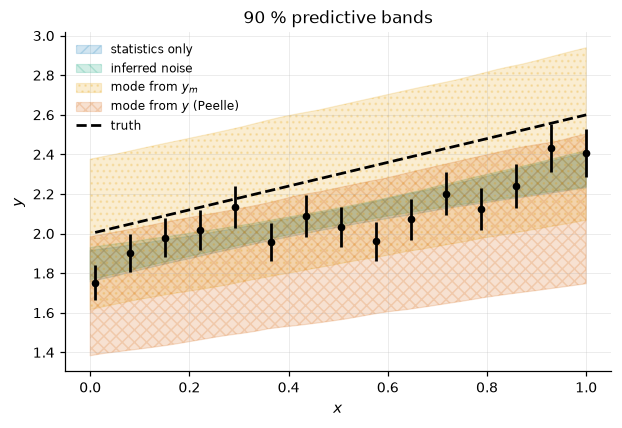

In [11]:
fig, ax = plt.subplots()
for label, (lo, hi) in bands.items():
    _, _, colour, hatch = runs[label]
    plotstyle.band(ax, x_fine, lo, hi, color=colour, hatch=hatch, label=label)
ax.plot(x, y_true, "--", color="k", label="truth")
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", ms=4)
ax.set(xlabel="$x$", ylabel="$y$", title="90 % predictive bands")
ax.legend(fontsize=8)
plt.show()

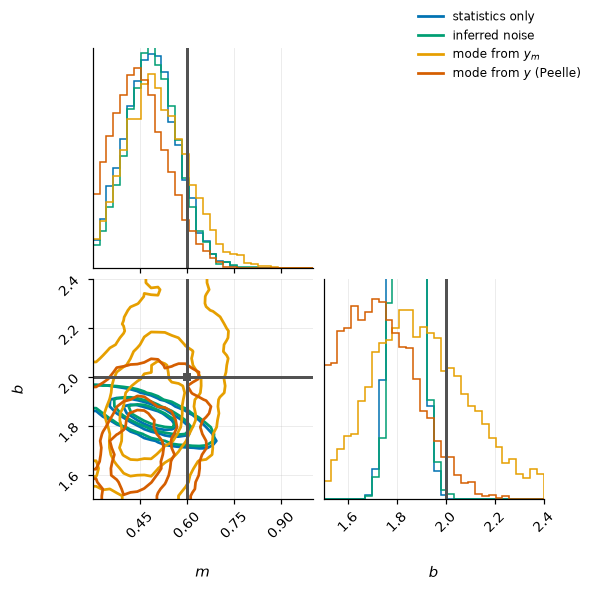

In [12]:
fig = None
for label, (p, s, colour, _) in runs.items():
    fig = corner.corner(
        s[:, p.columns(line.params)],
        fig=fig,
        labels=["$m$", "$b$"],
        truths=[truth["m"], truth["b"]],
        range=[(0.3, 1.0), (1.5, 2.4)],
        **plotstyle.corner_kwargs(
            color=colour, fill_contours=False, plot_density=False, show_titles=False
        ),
    )
fig.legend(
    handles=[
        plt.Line2D([], [], color=c, label=lab) for lab, (_, _, c, _) in runs.items()
    ],
    loc="upper right",
    fontsize=8,
)
plt.show()

Four covariances, four answers, and the truth is $m = 0.6$, $b = 2.0$.

Statistics only is the confident one: $b = 1.836 \pm 0.049$, more than three
standard deviations below the truth.  Nothing in that covariance can express a
shift common to every point, so the fit absorbs the 10 % normalisation into the
line itself and then tells us it is sure.

Inferring the noise *does* cover the truth ($m = 0.531 \pm 0.277$), but look at
what it cost.  The inferred noise came out at 6 %, above the 5 % the data were
really generated with, and the uncertainty on the slope roughly tripled.  A free
diagonal can only buy coverage by inflating every point independently, which is
not what happened to these data: it gets the right answer for the wrong reason,
and pays for it in precision.

The mode built from the prediction covers the truth at an honest width
($b = 1.917 \pm 0.220$).  It is the only one of the four that knows the defect
was a single number multiplying everything.

And the Peelle covariance, built from the data, is pulled further down *and* is
narrower than the honest one ($m = 0.439 \pm 0.097$ against
$0.503 \pm 0.104$) — confidently wrong, the worst of both.

## 5. Inferring a normalisation or an offset nobody reported (recipe 4)

The magnitude of the mode need not be known either.  `T.normalization(log_eta)`
samples it, and `T.offset(...)` does the same for an additive shift.  Here we
plant an offset defect and treat it three ways: with the magnitude known, with
it free, and by ignoring it.

In [13]:
offset = 0.3
y_off = y_true + rng.normal(0.0, noise_fraction * y_true) + offset
data_off = rx.Dataset(x, y_off, noise_fraction * y_off, label="offset")
comp_off = rx.Comparison(data_off, line)

log_omega = rx.Parameter(
    "log_omega", prior=stats.norm(np.log(0.3), 1.0), latex=r"\log\omega"
)
p_off_known = rx.Problem(
    [rx.Constraint([comp_off], terms=[T.offset(magnitude=offset)])]
)
p_off_free = rx.Problem([rx.Constraint([comp_off], terms=[T.offset(log_omega)])])
p_off_ignored = rx.Problem([rx.Constraint([comp_off])])

In [14]:
for name, p in [
    ("known", p_off_known),
    ("free", p_off_free),
    ("ignored", p_off_ignored),
]:
    s = fit(p, seed=5)
    print(f"offset {name:8s}: {summary(p, s)}")

offset known   : m = 0.535 +/- 0.109  b = 2.359 +/- 0.310


offset free    : m = 0.547 +/- 0.108  b = 2.553 +/- 0.725  log_omega = -1.140 +/- 1.013


offset ignored : m = 0.535 +/- 0.110  b = 2.301 +/- 0.061


## Takeaways

- The covariance *is* the statistical model.  Declaring it is the work; the
  inference machinery does not change from one rung of the ladder to the next.
- A defect the experiment never reported can be inferred: a noise level, a
  normalisation, an offset — each one more column in the chain.
- A correlated systematic is a mode built from the *prediction*.  Built from the
  data instead, it is Peelle's Pertinent Puzzle, and it will quietly pull the
  answer down.

When two experiments measure the same thing, the same question comes back one
level up: do they share a parameter, or do they share a mode?  That is
`sharing_error_models`, next door.